In [2]:
import pandas  as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [4]:
data_dir = 'gbfs_in_files'
station_status =pd.read_csv(os.path.join(data_dir, 'A1-station_status.csv')) 
station_info = pd.read_csv(os.path.join(data_dir, 'stations_selected.csv'))

## Exploratory Data Analysis

In [9]:
station_info.head(3)

,station_id,name,physical_configuration,lat,lon,altitude,address,cross_street,post_code,capacity,...,geofenced_capacity,rental_methods,is_virtual_station,groups,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,obcn,short_name
0,1,001 - CL 82 con KR 11,REGULAR,4.665803,-74.052844,NaN,Calle 82 entre Carrera 11 y Carrera 12,EL RETIRO,1111,19,...,0,"['KEY', 'TRANSITCARD', 'CREDITCARD', 'PHONE']",False,[],1000,f051,True,{},NaN,NaN
1,3,003 - KR 15 con CL 93,REGULAR,4.677735,-74.051530,NaN,Carrera 15 entre Calle 93 y Calle 93A,CHICO NORTE,1111,10,...,0,"['KEY', 'TRANSITCARD', 'CREDITCARD', 'PHONE']",False,[],1000,a946,True,{},NaN,NaN
2,4,004 - Parque de Japón,REGULAR,4.669821,-74.050483,NaN,Calle 86a entre Carrera 11 y Carrera 11a,LA CABRERA,1111,11,...,0,"['KEY', 'TRANSITCARD', 'CREDITCARD', 'PHONE']",False,[],1000,fcb9,True,{},NaN,NaN


In [7]:
station_status.head()

,station_id,status_uuid,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,city,last_reported_local_date
0,41,9c92e04f-b8be-4c46-a131-7c346f0a0fbe,4,6,50,0,1731382546,bogota_co,2024-11-11 22:35:46
1,46,7320e61b-9da9-434d-9b23-79d4ac0975a0,19,3,12,0,1731382581,bogota_co,2024-11-11 22:36:21
2,25,02c131d8-d4e5-493e-a394-6793cf8bd078,1,1,25,0,1731382585,bogota_co,2024-11-11 22:36:25
3,5,5de1cebc-4214-4d46-86f9-5e5c42e1b129,20,3,15,1,1731382629,bogota_co,2024-11-11 22:37:09
4,5,b467fd79-400f-4c6a-9207-e52c9d0b0309,5,0,33,1,1731999279,bogota_co,2024-11-19 01:54:39


In [12]:
## register last_reported_local_date as datetime dtype

## use timestamp in last_reported to create datetime column last_reported_local_date with local timezone Bogota
station_status['last_reported_local_date'] = pd.to_datetime(station_status['last_reported'], utc=True)
station_status['last_reported_local_date'] = station_status['last_reported_local_date'].dt.tz_convert('America/Bogota')	


<Axes: xlabel='last_reported_local_date', ylabel='num_bikes_available'>

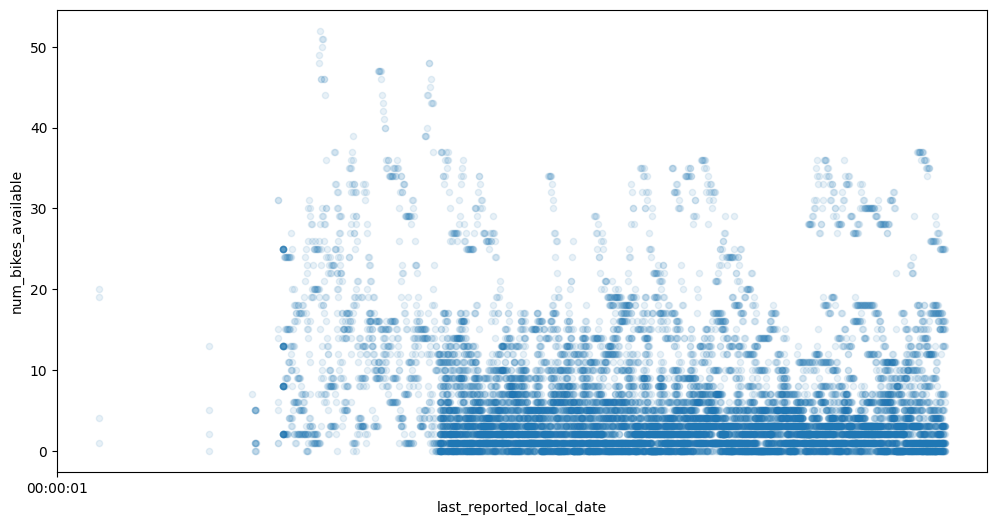

In [ ]:
# format x axis as date
station_status.plot(x='last_reported_local_date', y='num_bikes_available', kind='scatter', alpha=0.1, figsize=(12, 6))  

In [ ]:
### Merge tables